In [ ]:
import pandas as pd


# 1. Загрузка данных
df = pd.read_csv("https://code.s3.yandex.net/datasets/ds_s18t2_customer_segmentation.csv")

print(f"Типы данных в датасете: \n{df.dtypes}\n")
print(f"Количество пропусков по столбцам: \n{df.isna().sum()}\n")

print(f"Определяем возможные значения в колонке education: \n{df['education'].value_counts()}\n")
print(f"Определяем возможные значения в колонке marital_status: \n{df['marital_status'].value_counts()}\n")

Типы данных в датасете: 
id                            int64
year_birth                    int64
education                    object
marital_status               object
income                      float64
kids                          int64
date_first_purchase          object
days_since_last_purchase      int64
num_purchases_at_shop         int64
num_web_purchases             int64
avg_purchase_sum            float64
dtype: object

Количество пропусков по столбцам: 
id                          0
year_birth                  0
education                   0
marital_status              0
income                      0
kids                        0
date_first_purchase         0
days_since_last_purchase    0
num_purchases_at_shop       0
num_web_purchases           0
avg_purchase_sum            0
dtype: int64

Определяем возможные значения в колонке education: 
education
Graduation    149
Master        149
PhD           146
Basic         144
2n Cycle       12
Name: count, dtype: int64

Опреде

In [2]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

df = df.drop(columns='id') # Здесь удалите колонку id

# 2. Кодировка категориальных признаков
cat_cols = ['education', 'marital_status'] # Здесь добавьте две колонки, которые будем кодировать

df[cat_cols] = df[cat_cols].apply(LabelEncoder().fit_transform) # Применяем label encoder на категориальных признаках

# Оставляем только числовые признаки
X = df.select_dtypes(include=[np.number]).values

# 3. Масштабирование
X_scaled =  StandardScaler().fit_transform(X) # Здесь инициализируйте класс для нормализации данных и обучите его на X
print(X_scaled)

[[ 1.21750803 -0.39384837 -0.3965849  ... -1.14869212 -1.09810484
  -1.0911833 ]
 [-0.3433997  -1.2594492   1.49692392 ...  0.70791891 -0.43146447
   0.48902216]
 [ 1.35940873 -0.39384837 -0.3965849  ... -0.942402   -1.09810484
  -1.12775322]
 ...
 [ 0.72085557  0.47175245  0.2345847  ... -0.52982178  0.67960283
  -0.5317277 ]
 [-0.41435005 -2.12505002  0.2345847  ... -1.14869212 -1.3203183
  -1.07578544]
 [ 1.35940873 -0.39384837 -0.3965849  ... -1.14869212 -1.09810484
  -1.10465643]]


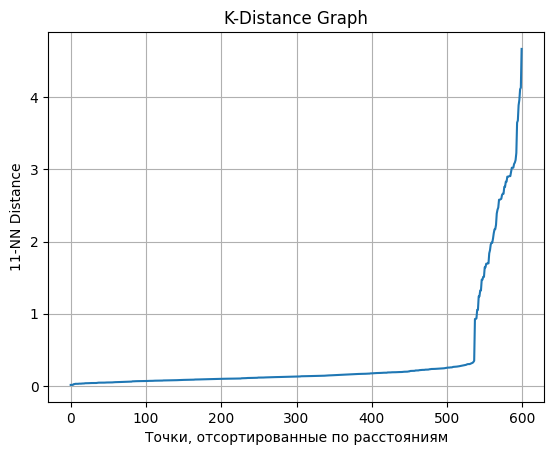

In [3]:
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Строим K-Distance Graph
knn = NearestNeighbors(n_neighbors = 11) # Определяем класс для построения графика
model = knn.fit(X_scaled) # Обучаем knn
distances, indices = knn.kneighbors(X_scaled) # Получаем индексы и расстояния
distances = np.sort(distances, axis=0) # Сортируем точки по расстояниям
distances = distances[:,1]

# рисуем график
plt.grid()
plt.plot(distances)
plt.xlabel('Точки, отсортированные по расстояниям')
plt.ylabel('11-NN Distance')
plt.title('K-Distance Graph')
plt.show()

На графике виден выраженный перегиб в диапазоне значений примерно от 0.3 до 3. Это указывает на характерные расстояния между точками в данных. Значения eps из этого диапазона подходят для запуска DBSCAN и позволяют получить осмысленные кластеры.

In [9]:
from sklearn.cluster import DBSCAN # здесь импортируйте необходимый класс

# Обучите кластеризатор DBSCAN
dbscan = DBSCAN(eps=1.0, min_samples=11) # Здесь объявите класс DBSCAN с параметрами eps и min_samples
labels = dbscan.fit_predict(X_scaled) # Здесь обучите кластеризатор на X_scaled

# Добавляем метки классов в датафрейм
df["cluster"] = labels

# Считаем, сколько точек в каждом кластере
print(df["cluster"].value_counts() / len(df)) # Здесь выведите количество точек в каждом кластере

cluster
 2    0.230
 0    0.225
 3    0.225
 1    0.220
-1    0.100
Name: count, dtype: float64


- Метод DBSCAN помечает шумы с помощью значения −1.

In [8]:
from sklearn.metrics import silhouette_score # здесь импортируйте необходимую функцию


mask = labels != -1 # Определяем маску для подсчёта метрики без шумов

score = silhouette_score(X=X_scaled[mask], labels=labels[mask]) # Здесь используйте данные X_scaled с маской и labels с маской

# Считаем силуэтный коэффициент
print(f"silhouette_score: {score:.4f}")

# Считаем процент шумов
noise = ... # Здесь посчитайте процент шумов в датафрейме df, где колонка cluster отвечает за кластер
print(f"Процент шумов: {noise}")

silhouette_score: 0.8744
Процент шумов: Ellipsis


## Исследование гиперпараметров


In [11]:
from sklearn.metrics import silhouette_score


eps_values = [0.2, 1, 3]  # Здесь определите все значения для eps
min_samples = 11 # Здесь укажите значение для min_samples

for eps in eps_values: # Здесь напишите цикл для перебора eps
    dbscan = DBSCAN(eps=eps, min_samples=min_samples) # Здесь объявите DBSCAN на указанных параметрах
    labels = dbscan.fit(X=X_scaled).labels_ # Определите кластеры на данных X_scaled

    mask = labels != -1 # Определяем маску для подсчёта метрики без шумов

    score = silhouette_score(X_scaled[mask], labels[mask]) # Здесь используйте данные X_scaled с маской и labels с маской
    noise_percent = len(labels[labels == -1]) / len(labels)
    print(f"Parameters: eps={eps}, min_samples={min_samples}. silhouette_score={score}, noise_percent={noise_percent}, labels={len(set(labels))}")  # количество кластеров с шумами

# visualize_clusters(X_scaled, labels) # Здесь вызовите функцию visualize_clusters() с необходимыми параметрами X_scaled, labels 

Parameters: eps=0.2, min_samples=11. silhouette_score=0.3329931592792341, noise_percent=0.5966666666666667, labels=9
Parameters: eps=1, min_samples=11. silhouette_score=0.8744151631223926, noise_percent=0.1, labels=5
Parameters: eps=3, min_samples=11. silhouette_score=0.5605583428880341, noise_percent=0.045, labels=3


In [12]:
from sklearn.metrics import silhouette_score


eps = 1 # Здесь укажите значение 1
min_samples_values = [1, 11, 22] # Здесь определите все значения для min_samples
for min_samples in min_samples_values:
  dbscan = DBSCAN(min_samples=min_samples, eps=eps) # Здесь объявите DBSCAN
  labels = dbscan.fit(X_scaled).labels_ # Здесь обучите DBSCAN на X_scaled

  mask = labels != -1 # Определяем маску для подсчёта метрики без шумов

  score = silhouette_score(X_scaled[mask], labels[mask]) # Здесь посчитайте silhouette_score на данных X_scaled с маской и labels с маской
  # Считаем процент шумов
  noise_percent = len(labels[labels == -1]) / len(labels)
  print(f"Parameters: eps={eps}, min_samples={min_samples}. silhouette_score={score}, noise_percent={noise_percent}, labels={len(set(labels))}") # количество кластеров с шумами

#   visualize_clusters(X_scaled[mask], labels[mask]) # Здесь вызовите функцию для визуализации с нужными параметрами

Parameters: eps=1, min_samples=1. silhouette_score=0.7748819289607053, noise_percent=0.0, labels=64
Parameters: eps=1, min_samples=11. silhouette_score=0.8744151631223926, noise_percent=0.1, labels=5
Parameters: eps=1, min_samples=22. silhouette_score=0.8744151631223926, noise_percent=0.1, labels=5
